This notebook captures the steps undertaken to train the LSTM model and fine tune the model. 

To perform the training on the hand co-ordinates data a script called (train.py)[scripts/train.py] is written. 

Here is a brief summary of what the script does. 

1.  This script loads the training dataset from JesterCoordinateDataset by using the raw co-ordinates files, using lables from annotation directory. 
2. This script also loads the validation dataset using jester-v1-validation dataset. 
3. It then constructs the model using GestureLSTM class from (model.py)
[scripts/model.py] script. GestureLSTM class provides an abstraction to construct a LSTM model by using PyTorch's nn library. Parameters to construct this model are passed from the training script. 
4. Once the model is constructed, the model uses the training dataset and validation dataset to continuously train the model for various epochs and measures the training loss, validation loss, training accuracy and validation accuracy. 
5. After the training phase the model saves the trained model as `.pth` file so that the model can be leveraged later for validation or fine tuning purposes. 

The following code demonstrates how the model is trained by invoking the train.py script

In [6]:
!python scripts/train.py --epochs 15 --lr 0.001 --batch_size 64 --hidden_size 128

Booting up unified training/validation engine on: mps
Loading massive coordinate CSV into Apple Silicon Unified Memory...
Grouping frames by video sequence...
Loading ground truth annotations...
Loading massive coordinate CSV into Apple Silicon Unified Memory...
Grouping frames by video sequence...
Loading ground truth annotations...
\n--- Starting Run: 15 Epochs | LR: 0.001 | Batch: 64 ---
Epoch [1/15] | Train Loss: 1.8348 | Val Loss: 1.1182 | Train Acc: 44.59% | Val Acc: 66.25%
Epoch [2/15] | Train Loss: 0.9715 | Val Loss: 0.8960 | Train Acc: 71.38% | Val Acc: 73.33%
Epoch [3/15] | Train Loss: 0.8043 | Val Loss: 0.7776 | Train Acc: 76.04% | Val Acc: 76.94%
Epoch [4/15] | Train Loss: 0.7272 | Val Loss: 0.7801 | Train Acc: 78.51% | Val Acc: 76.76%
Epoch [5/15] | Train Loss: 0.6756 | Val Loss: 0.7052 | Train Acc: 80.16% | Val Acc: 79.62%
Epoch [6/15] | Train Loss: 0.6323 | Val Loss: 0.6655 | Train Acc: 81.62% | Val Acc: 80.74%
Epoch [7/15] | Train Loss: 0.6040 | Val Loss: 0.6414 | Train

Data Saved from the Training and Validation Phase is plotted using the following code. 

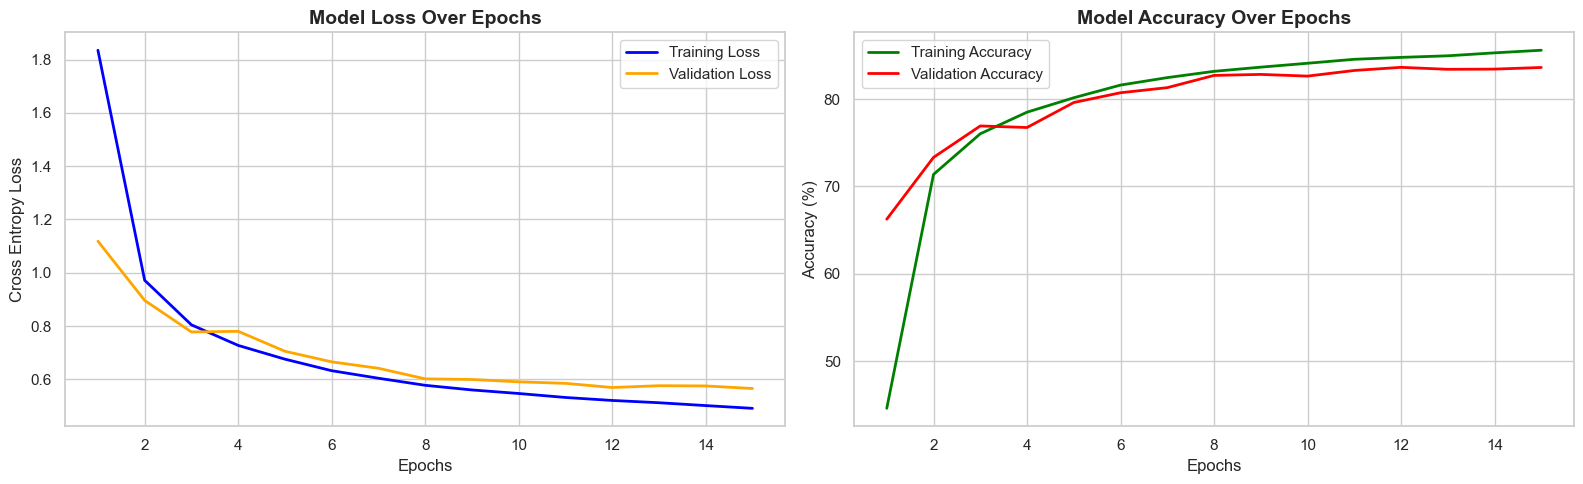

In [7]:
import json
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for professional  graphs
sns.set_theme(style="whitegrid")

# Load the history file generated by train.py
# (Update this filename if you ran a different parameter combination)
history_file = "history_h128_lr0.001.json"

with open(history_file, 'r') as f:
    history = json.load(f)

epochs = range(1, len(history['train_loss']) + 1)

# Create a 1x2 figure (Loss on left, Accuracy on right)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Loss Curve
ax1.plot(epochs, history['train_loss'], label='Training Loss', color='blue', linewidth=2)
ax1.plot(epochs, history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
ax1.set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Cross Entropy Loss', fontsize=12)
ax1.legend()

# Plot 2: Accuracy Curve
ax2.plot(epochs, history['train_acc'], label='Training Accuracy', color='green', linewidth=2)
ax2.plot(epochs, history['val_acc'], label='Validation Accuracy', color='red', linewidth=2)
ax2.set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.legend()

plt.tight_layout()
plt.show()